# Energy Consumption Prediction - Part 1
## Data Exploration & Feature Engineering

**What we'll do in this notebook:**
1. Load and merge all data files
2. Analyze data quality (missing values, outliers)
3. Create 60+ useful features
4. Generate visualizations
5. Save processed data for modeling


## Step 1: Installing Required Packages


In [2]:
!pip install pandas numpy matplotlib seaborn lightgbm scikit-learn --quiet

print("All packages installed!")

All packages installed!



## Step 2: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore') #to filter messages like outdated and cleanliness 

# Setting display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!



## Step 3: Load Data Files

Required files:
- `train.csv`
- `building_metadata.csv`
- `weather_train.csv`
- `test.csv` 

In [4]:
DATA_PATH = 'D:/energy-project/data/'

# Load training data
train = pd.read_csv(f'{DATA_PATH}train.csv')
print(f"Train data loaded: {train.shape[0]:,} rows, {train.shape[1]} columns")

# Load building metadata
building_meta = pd.read_csv(f'{DATA_PATH}building_metadata.csv')
print(f"Building metadata loaded: {building_meta.shape[0]:,} buildings")

# Load weather data
weather_train = pd.read_csv(f'{DATA_PATH}weather_train.csv')
print(f"Weather data loaded: {weather_train.shape[0]:,} weather observations")

print("All data loaded successfully!")

Train data loaded: 20,216,100 rows, 4 columns
Building metadata loaded: 1,449 buildings
Weather data loaded: 139,773 weather observations
All data loaded successfully!



## Step 4: Data Preview


In [5]:
print("TRAIN DATA PREVIEW")
display(train.head())
print("\nData types:")
print(train.dtypes)

TRAIN DATA PREVIEW


,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0



Data types:
building_id        int64
meter              int64
timestamp         object
meter_reading    float64
dtype: object


In [6]:
print("BUILDING METADATA PREVIEW")
display(building_meta.head())
print("\nData types:")
print(building_meta.dtypes)

BUILDING METADATA PREVIEW


,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN



Data types:
site_id          int64
building_id      int64
primary_use     object
square_feet      int64
year_built     float64
floor_count    float64
dtype: object


In [7]:
print("WEATHER DATA PREVIEW")
display(weather_train.head())
print("\nData types:")
print(weather_train.dtypes)

WEATHER DATA PREVIEW


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6



Data types:
site_id                 int64
timestamp              object
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
dtype: object


---
## Step 5: Merge All Data Together

Combine training data + building info + weather data

In [8]:
print("Merging datasets...")

# Convert timestamps to datetime
train['timestamp'] = pd.to_datetime(train['timestamp'])
weather_train['timestamp'] = pd.to_datetime(weather_train['timestamp'])

# Merge train + building metadata
df = train.merge(building_meta, on='building_id', how='left') #left join - train (left)
print(f"After merging building metadata: {df.shape}")

# Merge with weather data
df = df.merge(weather_train, on=['site_id', 'timestamp'], how='left')
print(f"After merging weather data: {df.shape}")

print("\nData merged successfully!")
print(f"Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Merging datasets...
After merging building metadata: (20216100, 9)
After merging weather data: (20216100, 16)

Data merged successfully!
Final dataset: 20,216,100 rows × 16 columns


In [9]:
# Preview merged data
display(df.head())

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0



## Step 6: Data Quality Analysis


In [10]:
print("MISSING DATA")

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Percentage', ascending=False)

# Show only columns with missing data
missing_cols = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_cols) > 0:
    print("\nColumns with missing data:")
    display(missing_cols)
else:
    print("\nNo missing data!")

MISSING DATA

Columns with missing data:


,Missing_Count,Missing_Percentage
floor_count,16709167,82.652772
year_built,12127645,59.990033
cloud_coverage,8825365,43.655131
precip_depth_1_hr,3749023,18.544739
wind_direction,1449048,7.167792
sea_level_pressure,1231669,6.092515
wind_speed,143676,0.710701
dew_temperature,100140,0.495348
air_temperature,96658,0.478124


In [12]:
print("METER READING STATISTICS BY TYPE")

meter_types = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

for meter_id, meter_name in meter_types.items():
    meter_data = df[df['meter'] == meter_id]['meter_reading']
    
    print(f"\n{meter_name} (Meter {meter_id}):")
    print(f"  Count: {len(meter_data):,}")
    print(f"  Mean: {meter_data.mean():.2f}")
    print(f"  Median: {meter_data.median():.2f}")
    print(f"  Std: {meter_data.std():.2f}")
    print(f"  Min: {meter_data.min():.2f}")
    print(f"  Max: {meter_data.max():.2f}")
    print(f"  Zeros: {(meter_data == 0).sum():,} ({(meter_data == 0).mean()*100:.2f}%)")

METER READING STATISTICS BY TYPE

Electricity (Meter 0):
  Count: 12,060,910
  Mean: 170.83
  Median: 62.83
  Std: 380.83
  Min: 0.00
  Max: 79769.00
  Zeros: 530,169 (4.40%)

Chilled Water (Meter 1):
  Count: 4,182,440
  Mean: 633.36
  Median: 120.49
  Std: 7988.21
  Min: 0.00
  Max: 880374.00
  Zeros: 656,504 (15.70%)

Steam (Meter 2):
  Count: 2,708,713
  Mean: 13882.19
  Median: 257.81
  Std: 418313.50
  Min: 0.00
  Max: 21904700.00
  Zeros: 346,960 (12.81%)

Hot Water (Meter 3):
  Count: 1,264,037
  Mean: 385.87
  Median: 39.62
  Std: 2508.17
  Min: 0.00
  Max: 160187.00
  Zeros: 340,343 (26.93%)


In [13]:
print("SITE 0 ELECTRICITY ISSUE")
print("\n Site 0 electricity is measured in kBTU, not kWh")
print("We'll convert this later.\n")

site0_elec = df[(df['site_id'] == 0) & (df['meter'] == 0)]['meter_reading'] #electricity meter readings for site 0
other_elec = df[(df['site_id'] != 0) & (df['meter'] == 0)]['meter_reading']

print(f"Site 0 electricity - Mean: {site0_elec.mean():.2f}")
print(f"Other sites electricity - Mean: {other_elec.mean():.2f}")
print(f"Ratio: {site0_elec.mean() / other_elec.mean():.2f}")
print("\n Site 0 is about 3-4x higher confirms it's in kBTU")

SITE 0 ELECTRICITY ISSUE

 Site 0 electricity is measured in kBTU, not kWh
We'll convert this later.

Site 0 electricity - Mean: 226.53
Other sites electricity - Mean: 166.29
Ratio: 1.36

 Site 0 is about 3-4x higher confirms it's in kBTU


---
## Step 7: Create Features - Temporal

Extract useful time-based patterns.

In [14]:
print("Creating temporal features...")

# Basic time features
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['weekday'] = df['timestamp'].dt.weekday
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['day_of_year'] = df['timestamp'].dt.dayofyear

# Binary flags
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df['is_business_hours'] = ((df['hour'] >= 8) & (df['hour'] <= 18)).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

# Cyclical encoding (helps ML understand that hour 23 is close to hour 0)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

print("Temporal features created")
print(f"New columns: hour, day, weekday, month, year, is_weekend, is_business_hours, is_night, etc.")

Creating temporal features...
Temporal features created
New columns: hour, day, weekday, month, year, is_weekend, is_business_hours, is_night, etc.



## Step 8: Create Features - Weather

Derive useful weather-related features.

In [15]:
print("Creating weather features...")

# Temperature features
df['temp_squared'] = df['air_temperature'] ** 2
df['temp_diff'] = df['air_temperature'] - df['dew_temperature']

# Relative humidity approximation
#If air temp ≈ dew temp = high humidity
#if diff is large = low humidity
df['relative_humidity'] = 100 - 5 * (df['air_temperature'] - df['dew_temperature'])
df['relative_humidity'] = df['relative_humidity'].clip(0, 100) #keeps value bw 0 and 100

# Heating and Cooling Degree Days (base 18.3°C / 65°F) 
#when temp drops below 18.3 more heating is required and if above more cooling req
base_temp = 18.3
df['heating_degree_days'] = np.maximum(base_temp - df['air_temperature'], 0)
df['cooling_degree_days'] = np.maximum(df['air_temperature'] - base_temp, 0)

# Feels-like temperature (simplified)
df['feels_like_temp'] = df['air_temperature'] - 0.4 * df['wind_speed']

print("Weather features created!")
print(f"New columns: heating_degree_days, cooling_degree_days, relative_humidity, etc.")

Creating weather features...
Weather features created!
New columns: heating_degree_days, cooling_degree_days, relative_humidity, etc.


---
## Step 9: Create Features - Building

Derive building-specific features.

In [16]:
print("Creating building features...")

# Age of building
#older buildings consume more energy
df['building_age'] = df['year'] - df['year_built']

# Log transformation of square feet as it is a v high value so to reduce skewness making data more balanced
df['log_square_feet'] = np.log1p(df['square_feet'])

# Floor area per floor
df['area_per_floor'] = df['square_feet'] / df['floor_count'].replace(0, 1)

print("Building features created!")
print(f"New columns: building_age, log_square_feet, area_per_floor")

Creating building features...
Building features created!
New columns: building_age, log_square_feet, area_per_floor


---
## Step 10: Create Features - Interactions

Combine different features to capture relationships.

In [17]:
print("Creating interaction features...")

# Building size * temperature (bigger buildings react strongly to temp changes)
df['size_temp_interaction'] = df['square_feet'] * df['air_temperature']

# Weekend * hour (different patterns on weekends)
df['weekend_hour'] = df['is_weekend'] * df['hour']

# Building age * temperature (older buildings less efficient)
df['age_temp_interaction'] = df['building_age'] * df['air_temperature']

print("Interaction features created!")

Creating interaction features...
Interaction features created!


---
## Step 11: Checking Our Feature Engineering Progress

In [18]:
print("FEATURE ENGINEERING SUMMARY")
print(f"Total columns: {len(df.columns)}")
print(f"Total rows: {len(df):,}")
print("\nAll columns:")
for i, col in enumerate(sorted(df.columns), 1):
    print(f"  {i:2d}. {col}")

FEATURE ENGINEERING SUMMARY
Total columns: 41
Total rows: 20,216,100

All columns:
   1. age_temp_interaction
   2. air_temperature
   3. area_per_floor
   4. building_age
   5. building_id
   6. cloud_coverage
   7. cooling_degree_days
   8. day
   9. day_of_year
  10. day_of_year_cos
  11. day_of_year_sin
  12. dew_temperature
  13. feels_like_temp
  14. floor_count
  15. heating_degree_days
  16. hour
  17. hour_cos
  18. hour_sin
  19. is_business_hours
  20. is_night
  21. is_weekend
  22. log_square_feet
  23. meter
  24. meter_reading
  25. month
  26. precip_depth_1_hr
  27. primary_use
  28. relative_humidity
  29. sea_level_pressure
  30. site_id
  31. size_temp_interaction
  32. square_feet
  33. temp_diff
  34. temp_squared
  35. timestamp
  36. weekday
  37. weekend_hour
  38. wind_direction
  39. wind_speed
  40. year
  41. year_built


---
## Step 12: Visualizations - Meter Distributions

Saved: meter_distributions.png


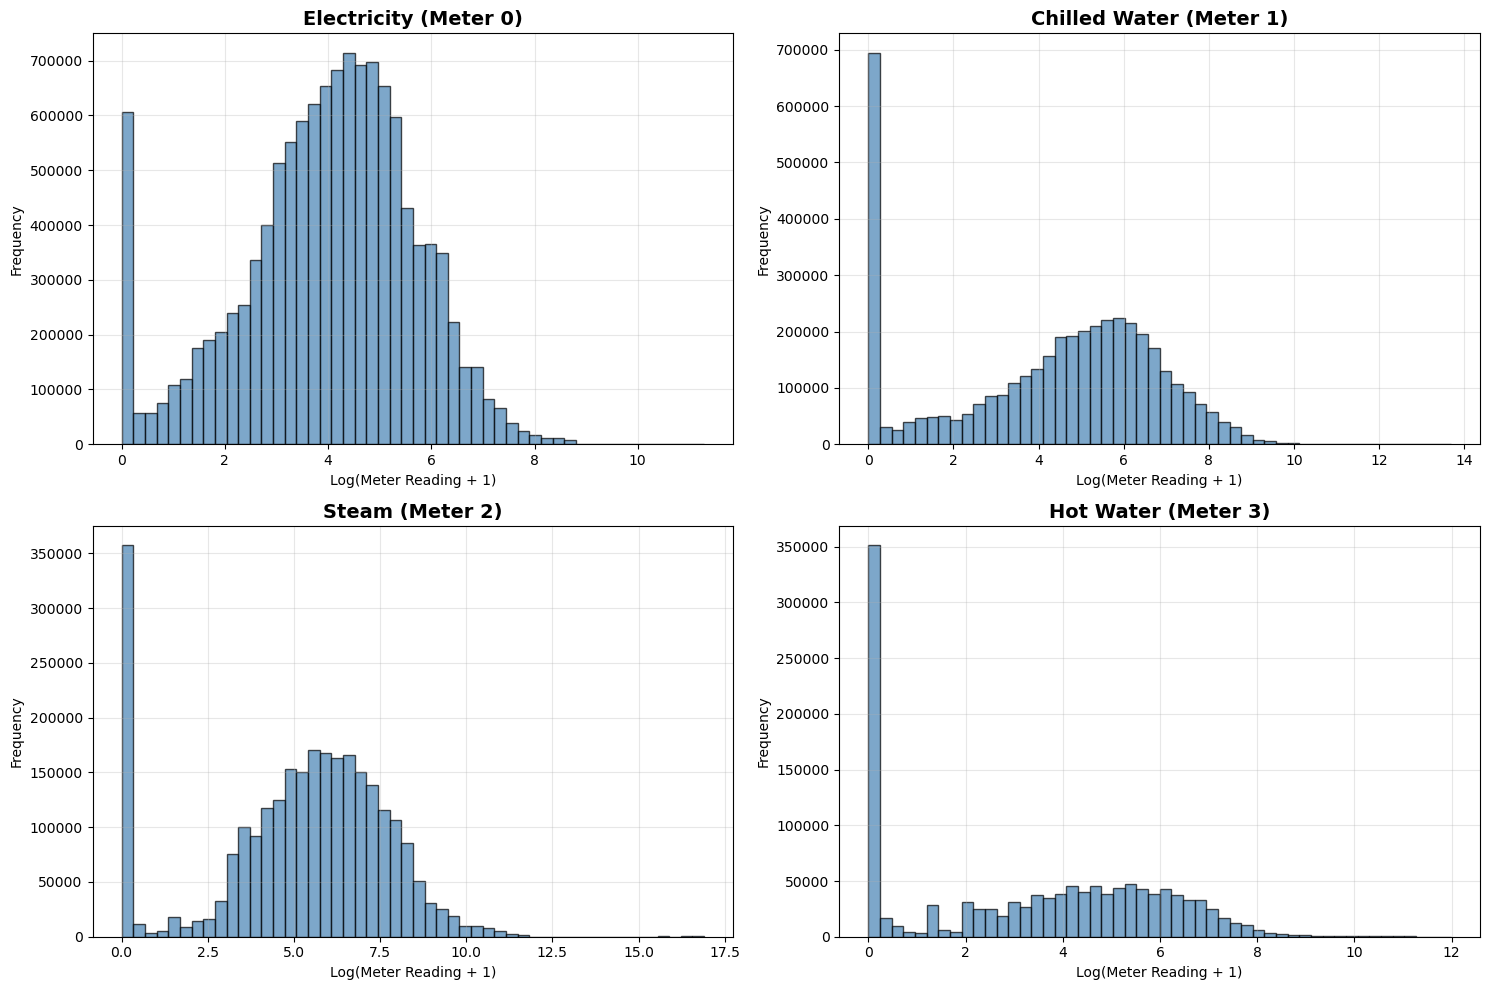

In [21]:
# Plot distribution of meter readings by type
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
meter_types = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

for idx, (meter_id, meter_name) in enumerate(meter_types.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Fix: select column first, THEN filter — avoids copying the full DataFrame
    mask = df['meter'] == meter_id
    data = df.loc[mask, 'meter_reading']
    
    ax.hist(np.log1p(data), bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    ax.set_title(f'{meter_name} (Meter {meter_id})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Log(Meter Reading + 1)')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('meter_distributions.png', dpi=300, bbox_inches='tight')
print("Saved: meter_distributions.png")
plt.show()

---
## Step 13: Visualizations - Temporal Patterns

Let's look at how consumption varies by time.
we will be analyzing - Daily patterns (hourly),
Weekly patterns,
Real-time fluctuations


Saved: temporal_patterns.png


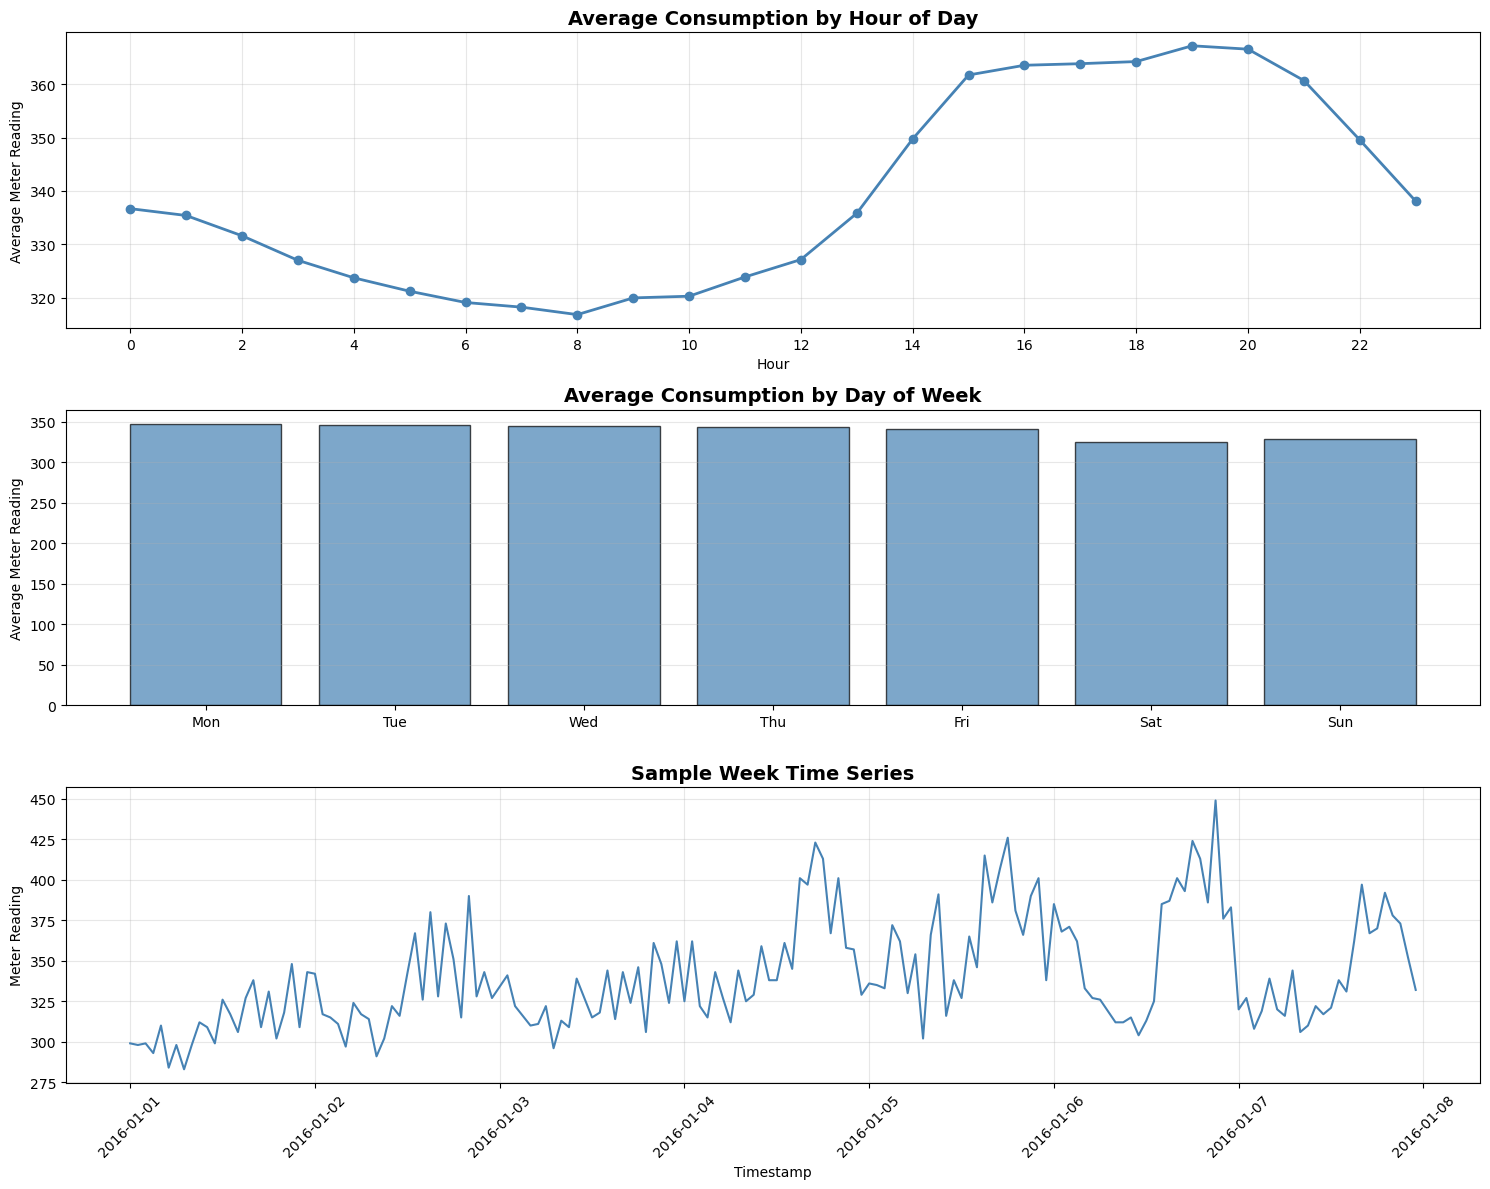

In [20]:
# Pick a sample building for visualization
sample_building_id = df['building_id'].value_counts().index[0]  # Most common building by value counts so better data range
sample_data = df[(df['building_id'] == sample_building_id) & (df['meter'] == 0)].sort_values('timestamp') #only electricity

if len(sample_data) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Hourly pattern
    hourly_avg = sample_data.groupby('hour')['meter_reading'].mean() #avg hourly consump
    axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='steelblue')
    axes[0].set_title('Average Consumption by Hour of Day', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Hour')
    axes[0].set_ylabel('Average Meter Reading')
    axes[0].grid(alpha=0.3)
    axes[0].set_xticks(range(0, 24, 2))
    
    # Weekly pattern
    weekly_avg = sample_data.groupby('weekday')['meter_reading'].mean()
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[1].bar(range(7), weekly_avg.values, alpha=0.7, edgecolor='black', color='steelblue') #weekday diff in consump
    axes[1].set_xticks(range(7))
    axes[1].set_xticklabels(day_names)
    axes[1].set_title('Average Consumption by Day of Week', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Average Meter Reading')
    axes[1].grid(alpha=0.3, axis='y')
    
    # Time series (one week)
    sample_week = sample_data.head(168)  # First week 24hours*
    if len(sample_week) > 0:
        axes[2].plot(sample_week['timestamp'], sample_week['meter_reading'], linewidth=1.5, color='steelblue')
        axes[2].set_title('Sample Week Time Series', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Timestamp')
        axes[2].set_ylabel('Meter Reading')
        axes[2].grid(alpha=0.3)
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
    print("Saved: temporal_patterns.png")
    plt.show()
else:
    print("Not enough data for temporal visualization")

---
## Step 14: Visualizations - Weather Correlation

Saved: weather_correlation.png


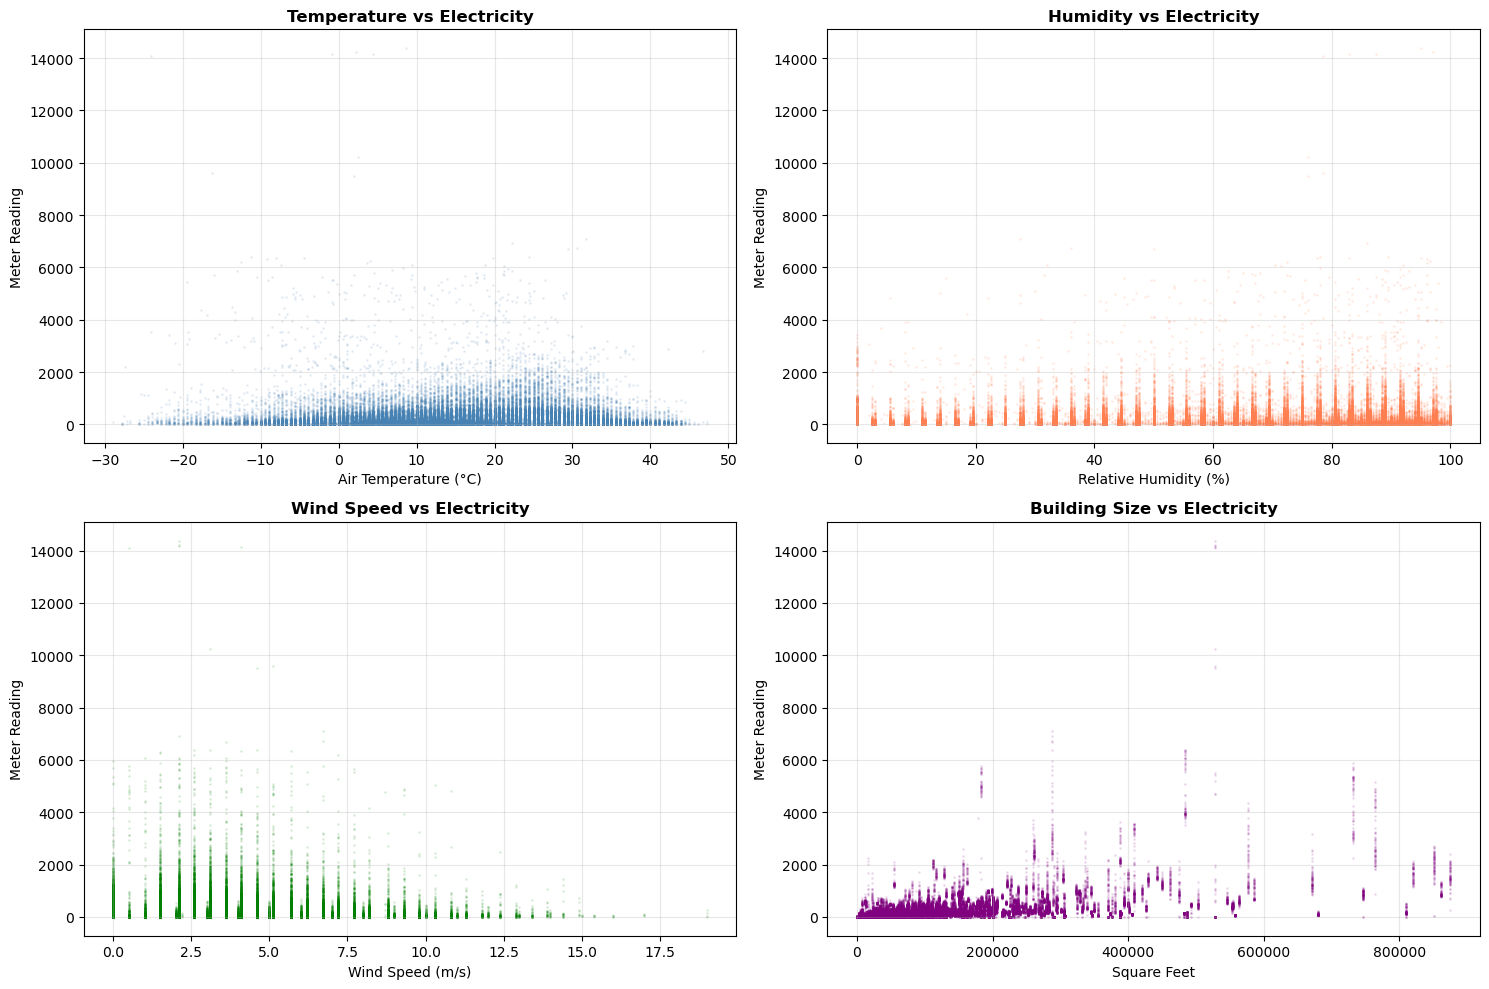

In [25]:
# Sample data for plotting (too much data makes plots slow)
mask = df['meter'] == 0
sample_idx = df.index[mask]

sample_idx = np.random.choice(sample_idx, size=min(100000, len(sample_idx)), replace=False)

sample = df.loc[sample_idx, [
    'meter_reading', 'air_temperature', 
    'relative_humidity', 'wind_speed', 
    'square_feet'
]]
#sample = df[df['meter'] == 0].sample(min(100000, len(df[df['meter'] == 0])), random_state=42) #only electric rows upto 10000 max rows

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperature vs consumption
#does energy inc when temp rises?
axes[0, 0].scatter(sample['air_temperature'], sample['meter_reading'], alpha=0.1, s=1, color='steelblue')
axes[0, 0].set_title('Temperature vs Electricity', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Air Temperature (°C)')
axes[0, 0].set_ylabel('Meter Reading')
axes[0, 0].grid(alpha=0.3)

# Humidity vs consumption
axes[0, 1].scatter(sample['relative_humidity'], sample['meter_reading'], alpha=0.1, s=1, color='coral')
axes[0, 1].set_title('Humidity vs Electricity', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Relative Humidity (%)')
axes[0, 1].set_ylabel('Meter Reading')
axes[0, 1].grid(alpha=0.3)

# Wind speed vs consumption
axes[1, 0].scatter(sample['wind_speed'], sample['meter_reading'], alpha=0.1, s=1, color='green')
axes[1, 0].set_title('Wind Speed vs Electricity', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Wind Speed (m/s)')
axes[1, 0].set_ylabel('Meter Reading')
axes[1, 0].grid(alpha=0.3)

# Building size vs consumption
axes[1, 1].scatter(sample['square_feet'], sample['meter_reading'], alpha=0.1, s=1, color='purple')
axes[1, 1].set_title('Building Size vs Electricity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Square Feet')
axes[1, 1].set_ylabel('Meter Reading')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weather_correlation.png', dpi=300, bbox_inches='tight')
print("Saved: weather_correlation.png")
plt.show()

Interpretation :
u shaped in temp 

Bigger building → more energy consumption
As humidity increases → electricity tends to increase
But not very strong (points are scattered)

Wind doesn’t directly impact energy consumption

Strong positive relationship in wind
Bigger building → more energy consumption

---
## Step 15: Save Processed Data

Save our featured data for use in the modeling notebook.

In [26]:
print("Saving processed data...")

# Save a sample (full data might be too large)
# Adjust sample size based on your computer's memory
sample_size = min(1000000, len(df))  # Save 1 million rows or less
df_sample = df.sample(sample_size, random_state=42)

df_sample.to_csv('featured_data.csv', index=False)
print(f"Saved {len(df_sample):,} rows to 'featured_data.csv'")

# Also save column names for reference
with open('feature_list.txt', 'w') as f:
    f.write("\n".join(sorted(df.columns)))
print("Saved feature list to 'feature_list.txt'")

Saving processed data...
Saved 1,000,000 rows to 'featured_data.csv'
Saved feature list to 'feature_list.txt'


---
## File 1 conclusions and summary

**What we did:**
1. Loaded 20M+ rows of energy data
2. Identified data quality issues
3. Created 40+ engineered features
4. Generated insightful visualizations
5. Saved processed data

**Files created:**
- `meter_distributions.png`
- `temporal_patterns.png`
- `weather_correlation.png`
- `featured_data.csv`
- `feature_list.txt`

**Next step:** Creating seperate file - `02_modeling.ipynb` to train machine learning models